<div style="background-color:white;padding:20px; color:black">
<h1 style= "background-color: #A72608; 
             text-align:left;
             color:white;
             font-weight:600;
             font-size:25px;
             border:0;
             border-left:solid 10px black;
             border-radius: 0px;
             padding: 20px 20px;"> 
Molecular Fingerprints
</h1>

 Deep learning models almost always take arrays of numbers as their inputs. But how can we turn a molecule into numbers.

Many (but not all) types of models require their inputs to have a fixed size. This can be a challenge for molecules, since different molecules have different numbers of atoms. If we want to use these types of models, we somehow need to represent variable sized molecules with fixed sized arrays.

Fingerprints are designed to address these problems. 

A fingerprint is a fixed length array, where different elements indicate the presence of different features in the molecule. If two molecules have similar fingerprints, that indicates they contain many of the same features, and therefore will likely have similar chemistry.
</div>

<div style="background-color:white;padding:5px; color:black;">
<h1 style= "background-color: #ffffff; 
             text-align:left;
             font-weight:600;
             color:crimson;
             font-size:25px;
             border-bottom:solid 2px gray;
             border-radius: 0px;
             padding: 0px 0px;"> 
Section I. 
</h1>
<h2 style= "background-color: #ffffff; 
             text-align:left;
             font-weight:600;
             color:#D2691E;
             margin:0em;
             font-size:20px;
             border-radius: 0px;
             padding: 0px 0px;"> 
Background
</h2>

[(i) What are molecular fingerprints]{style="color:brown;font-style:italic"}

[(ii) What are applications of fingerprints]{style="color:brown;font-style:italic"}

[(iii) What are some commonly used fingerprints]{style="color:brown;font-style:italic"}

Let's learn about some fingerprints and create them using `rdkit`:
- Molecular ACCess System keys or MACCS-keys
- Avalon fingerprint
- Atom-pair fingerprint
- Topological-Torsions fingerprint.
- Morgan fingerprint or Circular Fingerprint
- RDKit Fingerprint

[RDKit Documentation](https://www.rdkit.org/docs/GettingStartedInPython.html#feature-definitions-used-in-the-morgan-fingerprints)

</div>





In [1]:


import pandas as pd
import numpy as np
import seaborn as sn
#---------------------- RDKit packages
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
#------------------- progress bar
from tqdm import tqdm
#------------------- hide warning
import warnings
warnings.filterwarnings('ignore')


from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_useSVG = True

In [2]:
# dataset = pd.read_csv('https://raw.githubusercontent.com/gashawmg/HOMO-LUMO-Enegry-gap-Prediction/master/Orbital_Energies_input_data.csv')
dataset = pd.read_csv('Orbital_Energies_input_data.csv')
dataset.head(10)


,SMILES,Energygap
0,Cc1ccc(cc1)C(F)(F)F,197.749421
1,OC(=O)CCCCl,247.493942
2,CC(C)(Oc1ccc(CCNC(=O)c2ccc(Cl)cc2)cc1)C(=O)O,164.712327
3,Nc1ccc(Cl)c(Cl)c1,169.027707
4,C[C@@H](CCO)CCC=C(C)C,209.569808
5,OC(C=C)C=C,210.979194
6,O=N(=O)c1ccc(Cl)c(c1)N(=O)=O,168.833179
7,O=CC1CCCCC1,213.451579
8,COc1ccc(cc1)C#C,171.191985
9,Brc1cncnc1,188.344944


### Side note: Visualization

In [19]:
# Include 2D structure of molecules
# https://github.com/rdkit/rdkit/blob/master/rdkit/Chem/PandasTools.py

from rdkit.Chem import PandasTools
PandasTools.AddMoleculeColumnToFrame(dataset,'SMILES', 'Structure')
dataset.head()


,SMILES,Energygap,Structure
0,Cc1ccc(cc1)C(F)(F)F,197.749421,<rdkit.Chem.rdchem.Mol object at 0x14c01a1474a0>
1,OC(=O)CCCCl,247.493942,<rdkit.Chem.rdchem.Mol object at 0x14c01a147580>
2,CC(C)(Oc1ccc(CCNC(=O)c2ccc(Cl)cc2)cc1)C(=O)O,164.712327,<rdkit.Chem.rdchem.Mol object at 0x14c01a147270>
3,Nc1ccc(Cl)c(Cl)c1,169.027707,<rdkit.Chem.rdchem.Mol object at 0x14c01a1475f0>
4,C[C@@H](CCO)CCC=C(C)C,209.569808,<rdkit.Chem.rdchem.Mol object at 0x14c01a147660>


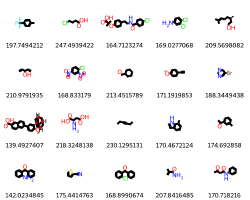

In [17]:
from rdkit.Chem import Draw

mols_to_draw = dataset["Structure"][:20]        #Take the first 20 molecules in dataset["Structures"] column

Draw.MolsToGridImage(                           #Draw molecules 
  mols_to_draw, 
  maxMols=100, 
  legends=[str(x) for x in dataset.Energygap], 
  subImgSize=(50,50), 
  molsPerRow=5)



<div style="background-color:#F0E68C;padding:5px; color:black">

<h2 style= "text-align:left;
             color:#556B2F;
             font-weight:bold;
             font-size:25px;
             border-radius: 0px;
             padding: 10px 10px;"> 
Task</h2>

1. Make the image size bigger.
2. Increase the number of molecules per row.
3. Round off the legend to two decimal places.
4. Instead of the Energy gap, have the SMILES string be the legend

<details name="my-tabs" style="color:#800000">
  <summary>Hint: </summary>
  <div class="tab-content" style="font-weight:bold;color:green;padding:0em 1em">
    <p>None.</p>
  </div>
</details>
</div>

<div style="background-color:white;padding:5px; color:black;">
<h1 style= "background-color: #ffffff; 
             text-align:left;
             font-weight:600;
             color:crimson;
             font-size:25px;
             border-bottom:solid 2px gray;
             border-radius: 0px;
             padding: 0px 0px;"> 
Section II. 
</h1>
<h2 style= "background-color: #ffffff; 
             text-align:left;
             font-weight:600;
             color:#D2691E;
             margin:0em;
             font-size:20px;
             border-radius: 0px;
             padding: 0px 0px;"> 
Some Fingerprints
</h2>


</div>





<div style= "background-color: #efcb68; 
             text-align:left;
             color:black;
             font-size:25px;
             border-radius: 0px;
             padding: 20px 20px;"> 
1. MACCS-keys Fingerprint (166 public keys)
 </div>

AttributeError: module 'rdkit.Chem.Draw.rdMolDraw2D' has no attribute 'MolDraw2DCairo'

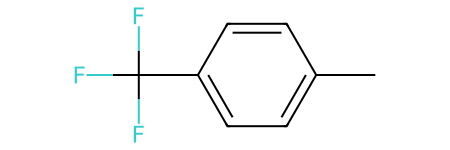

In [36]:
dataset.Structure[0]

In [21]:
# Generate MACCS (Molecular ACCess System) keys
from rdkit.Chem import MACCSkeys
Mkeys = MACCSkeys.GenMACCSKeys(dataset.Structure[0])

# Use numpy array to see On and Off bits
print(np.array(Mkeys))
print("MACCS keys: ", len(Mkeys))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0]
MACCS keys:  167


But which bits are on?

In [33]:
# Color codes
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m'
BLUE = '\033[34m'
RESET = '\033[0m'

In [35]:
# print On bits
print(f"{BLUE}Index of On bits:{RESET}", np.nonzero(Mkeys)[0])
# how many bits are On?
print(f"{BLUE}Number of On bits:{RESET}", np.count_nonzero(Mkeys))

Index of On bits: [ 42 106 107 112 134 160 162 163 165]
Number of On bits: 9


 <div style= "background-color: #efcb68; 
             text-align:left;
             color:black;
             font-size:25px;
             border-radius: 0px;
             padding: 20px 20px;"> 
 2. Avalon Fingerprint
 </div>

Avalon uses a fingerprint generator that enumerates
certain paths and feature classes of the molecular graph.[reference](https://pubs.acs.org/doi/pdf/10.1021/ci050413p)

In [37]:
# Calculate Avalon fingerprints
from rdkit.Avalon import pyAvalonTools
Av = pyAvalonTools.GetAvalonFP(dataset.Structure[0], nBits=512)
print(np.array(Av))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

In [38]:
# print On bits
print("Index of On bits:",tuple(Av.GetOnBits()))
# how many bits are On?
print("Number of On bits: ",len(Av.GetOnBits()))

Index of On bits: (18, 58, 67, 81, 92, 124, 138, 150, 153, 157, 196, 198, 206, 207, 221, 222, 234, 250, 266, 274, 282, 293, 305, 324, 328, 333, 341, 343, 351, 367, 383, 389, 390, 401, 455, 464, 472, 478, 508)
Number of On bits:  39



<div style= "background-color: lightcyan; border-style:dotted;text-align:left;color:blue;font-size:20px;border-radius: 10px;padding: 20px 20px;"> 
5. Morgan-Circular Fingerprints (Circular Fingerprints)
</div>

Reference [RDKit blog](https://rdkit.blogspot.com/2018/10/using-new-fingerprint-bit-rendering-code.html)


In [40]:
onbits = {}
mf = AllChem.GetMorganFingerprintAsBitVect(dataset.Structure[0], 2, nBits=512, bitInfo=onbits)
print(np.array(mf))


# print On bits
print("Index of On bits:",tuple(mf.GetOnBits()))
# how many bits are On?
print("Number of On bits: ",len(mf.GetOnBits()))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

[10:34:27] DEPRECATION WARNING: please use MorganGenerator


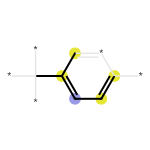

In [42]:
# Which fragment makes a bit ON? or  display the feature that turn a bit ON?

Draw.DrawMorganBit(dataset.Structure[0], 129, onbits)

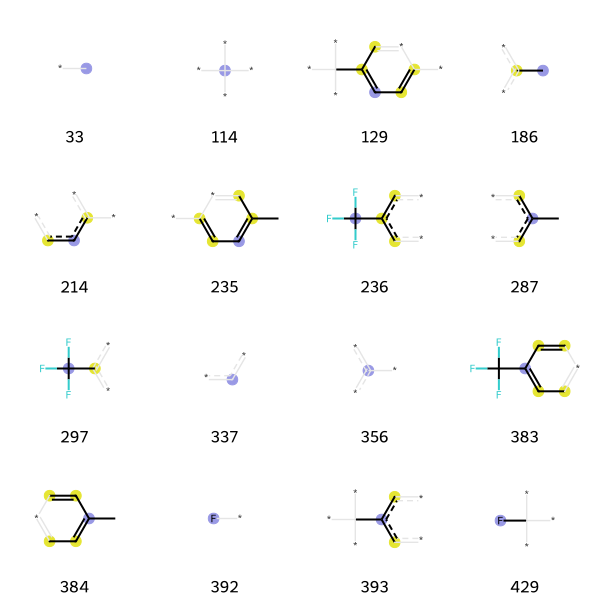

In [43]:
# Render all the fragments or features that are responsible for making ON bits
all_fragments = [(dataset.Structure[0], x, onbits) for x in mf.GetOnBits()]
Draw.DrawMorganBits(all_fragments[:],molsPerRow=4, legends=[str(x) for x in mf.GetOnBits()][:])

## ECFP

A particular type of fingerprint is a "Circular Fingerprint", also called an "Extended Connectivity Fingerprint", or "ECFP" for short. 

The ECFP algorithm begins by classifying atoms based only on their direct properties and bonds. Each unique pattern is a feature. For example, "carbon atom bonded to two hydrogens and two heavy atoms" would be a feature, and a particular element of the fingerprint is set to 1 for any molecule that contains that feature. It then iteratively identifies new features by looking at larger circular neighborhoods. One specific feature bonded to two other specific features becomes a higher level feature, and the corresponding element is set for any molecule that contains it. This continues for a fixed number of iterations, most often two. 

## Sources

A number of online tutorials were used to create this notebook. 

https://github.com/gashawmg/Molecular-fingerprints/blob/main/Calculating%20molecular%20fingerprints%20available%20in%20RDkit%20.ipynb

    

